In [19]:
import qutip as qt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy.stats import norm


############################################################################################
# definition for all the basis and pauli matrix
paulis = {
    "X": qt.sigmax(),
    "Y": qt.sigmay(),
    "Z": qt.sigmaz()
}

ket0 = qt.basis(2, 0)
ket1 = qt.basis(2, 1)

pauli_eigen = {
    'Z': {+1: ket0, -1: ket1},
    'X': {+1: (ket0 + ket1).unit(),
          -1: (ket0 - ket1).unit()},
    'Y': {+1: (ket0 + 1j*ket1).unit(),
          -1: (ket0 - 1j*ket1).unit()}
}

############################################################################################

def random_pauli():
    key = np.random.choice(list(paulis.keys()))
    return key, paulis[key]

def projector_on_qubit(eigvec, qubit_index, qubit_num):
    ops = []
    for i in range(qubit_num):
        if i == qubit_index:
            ops.append(eigvec * eigvec.dag())
        else:
            ops.append(qt.qeye(2))
    return qt.tensor(ops)
    

def shadow_measurement(rho, qubit_num):
    measurement_list = []

    for q in range(qubit_num):
        label, op = random_pauli()
        eigvals, eigvecs = op.eigenstates()

        proj = {}
        for val, vec in zip(eigvals, eigvecs):
            proj[int(np.sign(val))] = projector_on_qubit(vec, q, qubit_num)

        probs = [
            qt.expect(proj[+1], rho),
            qt.expect(proj[-1], rho)
        ]

        probs = np.real(probs)
        probs = np.clip(probs, 0.0, 1.0)
        probs /= probs.sum()

        outcome = np.random.choice([+1, -1], p=probs)
        measurement_list.append((label, outcome))

    return measurement_list

            
def create_classical_shadow(data, qubit_num):
    shadow_list = []
    for shot in data:
        rhohat_single_shot = []
        for pauli, outcome in shot:
            ket = pauli_eigen[pauli][outcome]
            proj = ket * ket.dag()
            rhohat_single_shot.append(3 * proj - qt.qeye(2))

        shadow_list.append(qt.tensor(rhohat_single_shot))

    return shadow_list

def estimation_mean(shadow_list, operator, shots):
    values = np.array([
        qt.expect(operator, shadow_list[s])
        for s in range(shots)
    ], dtype=float)

    mean_estimator = np.mean(values)
    return mean_estimator

def estimation_median_of_means(shadow_list, operator, shots, group_number):
    """
    Median-of-means estimator for <operator>

    Parameters
    ----------
    shadow_list : list of Qobj
        Classical shadow estimators (length >= shots)
    operator : Qobj
        n-qubit observable
    shots : int
        Number of shots to use
    group_number : int
        Number of groups for MoM

    Returns
    -------
    float
        Median-of-means estimate of Tr(rho * operator)
    """

    if shots % group_number != 0:
        raise ValueError("shots must be divisible by group_number")

    group_size = shots // group_number

    # Compute per-shot estimates
    values = np.array([
        qt.expect(operator, shadow_list[s])
        for s in range(shots)
    ], dtype=float)

    # Split into groups
    group_means = []
    for g in range(group_number):
        start = g * group_size
        end = (g + 1) * group_size
        group_means.append(np.mean(values[start:end]))

    return np.median(group_means)

In [20]:
def create_random_pauli_obs(qubit_num):
    pauli_obs_list=[]
    for q in range(qubit_num):
        label, op = random_pauli()
        pauli_obs_list.append(label)
    return pauli_obs_list

def pauli_measurement(rho, pauli_obs_list):
    measurement_list = []
    for i,pauli_label in enumerate(pauli_obs_list):
        op = paulis[pauli_label]
        eigvals, eigvecs = op.eigenstates()

        proj = {}
        for val, vec in zip(eigvals, eigvecs):
            proj[int(np.sign(val))] = projector_on_qubit(vec, i, qubit_num)

        probs = [
            qt.expect(proj[+1], rho),
            qt.expect(proj[-1], rho)
        ]

        probs = np.real(probs)
        probs = np.clip(probs, 0.0, 1.0)
        probs /= probs.sum()

        outcome = np.random.choice([+1, -1], p=probs)
        measurement_list.append((pauli_label, outcome))

    return measurement_list

        

In [21]:
# definition of qubits and state, here the state is n tensor product of |+> 
qubit_num  = 2

# Define a quantum state |+>
all_qubit = [(ket0+ket1).unit() for i in range(qubit_num)]
psi = qt.tensor(all_qubit)

# difine operator as \sigma_x \otimes \sigma_x \cdots for simplicity. estimations should be around 1
operator = qt.tensor(qt.sigmax(), qt.qeye(2))

rho = psi * psi.dag()
tlist = np.linspace(0, 2*np.pi, 2000)
####################################################################################
# definition of quantum dynamic
H = qt.tensor(qt.sigmaz(), qt.sigmaz())

gamma = 0.1
c_ops = [np.sqrt(gamma) * qt.tensor(qt.sigmaz(), qt.qeye(2))]
# result = qt.mesolve(H, psi, tlist, c_ops) # with damping
result = qt.mesolve(H, psi, tlist, []) # without damping

# list of times for which the solver should store the state vector



# result = qt.mesolve(H, psi0, tlist, [], e_ops=qt.sigmaz())
# expect = qt.expect(operator, result.states)

In [22]:
import torch
import gpytorch
from gpytorch.kernels import RBFKernel, ScaleKernel, MaternKernel, PolynomialKernel, PeriodicKernel
from gpytorch.means import ZeroMean, ConstantMean
from gpytorch.distributions import MultivariateNormal
from gpytorch.likelihoods import FixedNoiseGaussianLikelihood
from botorch.models.gpytorch import GPyTorchModel
from torch.distributions import Bernoulli, Normal
from project3_helpers import (
    build_dataset,
    print_dataset_diagnostics,
    compute_empirical_p,
    make_inducing_points,
    mae_against_true,
    aggregate_by_time,
)


In [23]:
# Reproducibility (restart & run all friendly)
np.random.seed(0)
torch.manual_seed(0)


In [24]:
class MyCustomKernel(gpytorch.kernels.Kernel):
    has_lengthscale = True  # learnable lengthscale

    def forward(self, x1, x2, diag=False, **params):
        # Pairwise squared Euclidean distance
        diff = (x1.unsqueeze(-2) - x2.unsqueeze(-3)).pow(1).sum(-1)
        K = torch.exp(-0.5 * diff / self.lengthscale**2)  # RBF kernel
        if diag:
            return K.diagonal(dim1=-2, dim2=-1)
        return K

class GPBinaryPrior(gpytorch.models.ExactGP, GPyTorchModel):
    _num_outputs = 1

    def __init__(self, train_x, train_y):
        # Dummy Gaussian likelihood required by ExactGP,
        # but we won't use it.
        likelihood = gpytorch.likelihoods.GaussianLikelihood()
        super().__init__(train_x, train_y, likelihood)

        self.mean_module = ConstantMean()
        self.mean_module.initialize(constant=0.0)
        # MaternKernel(nu=0.5)
        self.covar_module = ScaleKernel(gpytorch.kernels.PeriodicKernel())
        self.covar_module.base_kernel.initialize(period_length=1.0)
        self.covar_module.base_kernel.initialize(period_length=1.0)
        self.covar_module.base_kernel.initialize(period_length=1.0)
        # self.covar_module = ScaleKernel(MyCustomKernel())

    def forward(self, x):
        mean = self.mean_module(x)
        covar = self.covar_module(x)
        return MultivariateNormal(mean, covar)

class GPBinaryModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)

        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = ScaleKernel(gpytorch.kernels.PeriodicKernel())
        # If your signal is periodic, use instead:
        # gpytorch.kernels.PeriodicKernel()

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)




class GPBinaryVI(gpytorch.models.ApproximateGP):
    def __init__(self, inducing_points):
        variational_distribution = gpytorch.variational.CholeskyVariationalDistribution(
            inducing_points.size(0)
        )
        variational_strategy = gpytorch.variational.VariationalStrategy(
            self,
            inducing_points,
            variational_distribution,
            learn_inducing_locations=True
        )
        super().__init__(variational_strategy)

        # Mean and kernel
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = ScaleKernel(gpytorch.kernels.PeriodicKernel())

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)





In [25]:
def train_gp_classifier(train_x, train_y, num_inducing=64, training_iter=1500, lr=0.01, print_every=100, patience=200, period_length=1.0):
    inducing_points = make_inducing_points(train_x, num_inducing)
    model = GPBinaryVI(inducing_points)
    model.covar_module.base_kernel.period_length = period_length
    likelihood = gpytorch.likelihoods.BernoulliLikelihood()

    model.train()
    likelihood.train()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=train_y.size(0))
    best_loss = None
    best_iter = 0
    for i in range(training_iter):
        optimizer.zero_grad()
        output = model(train_x)
        loss = -mll(output, train_y)
        if torch.isnan(loss):
            raise ValueError('NaN loss encountered')
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        if best_loss is None or loss.item() < best_loss - 1e-4:
            best_loss = loss.item()
            best_iter = i
        elif (i - best_iter) > patience:
            print(f'Early stop at iter {i+1}, best loss {best_loss:.4f}')
            break

        if (i + 1) % print_every == 0:
            print(f'Iter {i+1}/{training_iter} - Loss: {loss.item():.4f}')

    return model, likelihood

def predict_gp_classifier(model, likelihood, test_x, num_samples=200):

    model.eval()
    likelihood.eval()

    with torch.no_grad():
        latent_dist = model(test_x)
        predictive_dist = likelihood(latent_dist)
        prob_mean = predictive_dist.mean

        f_samples = latent_dist.rsample(torch.Size([num_samples]))
        prob_samples = likelihood(f_samples).probs
        lower = torch.quantile(prob_samples, 0.025, dim=0)
        upper = torch.quantile(prob_samples, 0.975, dim=0)

    return prob_mean, lower, upper, latent_dist.mean, latent_dist.variance


In [26]:
class GPRegressionModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = ConstantMean()
        self.covar_module = ScaleKernel(PeriodicKernel())
        self.covar_module.base_kernel.initialize(period_length=1.0)

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return MultivariateNormal(mean_x, covar_x)


def train_gp_regression(train_x, train_y, noise_var, training_iter=300, lr=0.05, print_every=50, period_length=1.0):
    likelihood = FixedNoiseGaussianLikelihood(noise=noise_var)
    model = GPRegressionModel(train_x, train_y, likelihood)
    model.covar_module.base_kernel.period_length = period_length

    model.train()
    likelihood.train()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    for i in range(training_iter):
        optimizer.zero_grad()
        output = model(train_x)
        loss = -mll(output, train_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        if (i + 1) % print_every == 0:
            print(f'[reg] Iter {i+1}/{training_iter} - Loss: {loss.item():.4f}')

    return model, likelihood


def predict_gp_regression(model, likelihood, test_x):
    model.eval()
    likelihood.eval()
    with torch.no_grad():
        pred = likelihood(model(test_x))
        mean = pred.mean
        var = pred.variance
    return mean, var


In [27]:
# N = 15                      # number of points you want
# sigma = 1                 # concentration width
# t_array = np.asarray(tlist) # ensure numpy array

# # Build density over existing grid
# density = (
#     np.exp(-(t_array - 0)**2 / (2*sigma**2)) +
#     np.exp(-(t_array - np.pi/2)**2 / (2*sigma**2)) +
#     np.exp(-(t_array - np.pi)**2 / (2*sigma**2)) +
#     np.exp(-(t_array - np.pi*3/2)**2 / (2*sigma**2)) +
#     np.exp(-(t_array - 2*np.pi)**2 / (2*sigma**2))
# )

# # Normalize
# density = density / density.sum()

# # Sample indices directly (no replacement!)
# indices = np.random.choice(
#     len(t_array),
#     size=N,
#     replace=False,
#     p=density
# )

# # Sort for chronological order
# indices = np.sort(indices)
# picked_times = t_array[indices]

In [28]:
def build_measurement_df(shadow_size, indices, result, tlist, qubit_num):
    obs_list = [create_random_pauli_obs(qubit_num) for _ in range(shadow_size)]
    records = []
    for idx in indices:
        rho = result.states[idx] * result.states[idx].dag()
        time = tlist[idx]
        for shadow_id in range(shadow_size):
            obs = obs_list[shadow_id]
            measurements = pauli_measurement(rho, obs)
            for qubit, (pauli_label, outcome) in enumerate(measurements):
                records.append({
                    'time': time,
                    'shadow_id': shadow_id,
                    'qubit': qubit,
                    'pauli': pauli_label,
                    'outcome': outcome,
                })
    return pd.DataFrame(records)


In [29]:
indices = np.linspace(0, len(tlist) - 1, 15, dtype=int)
picked_times = tlist[indices]

shadow_size = 300
qubit_num  = 2

obs_list = []
for i in range(shadow_size):
    obs = create_random_pauli_obs(qubit_num)
    obs_list.append(obs)
records = []

for idx in indices:
    rho = result.states[idx] * result.states[idx].dag()
    time = tlist[idx]
    for shadow_id in range(shadow_size):
        obs = obs_list[shadow_id]
        measurements = pauli_measurement(rho, obs)

        for qubit, (pauli_label, outcome) in enumerate(measurements):
            records.append({
                # "time_idx": time_idx,
                "time": time,
                "shadow_id": shadow_id,
                "qubit": qubit,
                "pauli": pauli_label,
                "outcome": outcome,
            })

measurement_df = pd.DataFrame(records)

print(measurement_df)

          time  shadow_id  qubit pauli  outcome
0     0.000000          0      0     X        1
1     0.000000          0      1     Y       -1
2     0.000000          1      0     X        1
3     0.000000          1      1     Y       -1
4     0.000000          2      0     Y        1
...        ...        ...    ...   ...      ...
8995  6.283185        297      1     Z        1
8996  6.283185        298      0     X        1
8997  6.283185        298      1     Z        1
8998  6.283185        299      0     X        1
8999  6.283185        299      1     Z       -1

[9000 rows x 5 columns]


In [30]:
# # find only X \otimes 1

# data = measurement_df[
#     (measurement_df["qubit"] == 0) &
#     (measurement_df["pauli"] == 'X')
# ]
# print(len(data))

# shadows = data["shadow_id"].unique()

# probs_sum = None
# size = 0

# # probs_list = []
# mu_list = []
# var_list = []

# for s in shadows:
#     shadow_data = data[data["shadow_id"] == s]
#     if shadow_data.empty:
#         continue

#     train_x = torch.tensor(shadow_data['time'].to_numpy(), dtype=torch.float32).unsqueeze(-1)
#     train_y = torch.tensor(shadow_data['outcome'].to_numpy(), dtype=torch.float32)

#     test_x = torch.tensor(tlist, dtype=torch.float32).unsqueeze(-1)

#     model = GPBinaryPrior(train_x, train_y)
#     mean_star, var_star = Bayesian_process(model, train_x, train_y, test_x)

#     # print(mean_star.shape)
#     # print(var_star.shape)

#     # if prob_tensor.ndim == 2:
#     #     probs = torch.diagonal(prob_tensor)
#     # else:
#     #     probs = prob_tensor

#     # probs_list.append(probs)
#     mu_list.append(mean_star)
#     var_list.append(var_star)

# Stack and average
# probs_mean = torch.stack(probs_list).mean(dim=0)


# Explain this notebook
We simulate random Pauli measurements (X/Y/Z) on a qubit and build a dataset of outcomes.
For each Pauli basis, we model the probability of outcome +1 as a function of time using a GP classifier.
The GP models a latent f(t) and maps it to probability via a Bernoulli likelihood.
More shots should reduce uncertainty and improve accuracy as the dataset grows.


In [31]:
# Main GP classification pipeline (use all data for each Pauli)
normalize_time_flag = True
use_aggregated = False
paulis_to_fit = ['X', 'Y', 'Z']
t_min = float(tlist.min())
t_max = float(tlist.max())
if normalize_time_flag:
    t_norm = (tlist - t_min) / (t_max - t_min)
    test_x = torch.tensor(t_norm, dtype=torch.float32).unsqueeze(-1)
else:
    test_x = torch.tensor(tlist, dtype=torch.float32).unsqueeze(-1)
results = {}
if not use_aggregated:
    for pauli in paulis_to_fit:
        train_x, train_y, data_filt, _, _ = build_dataset(
            measurement_df, qubit=0, pauli=pauli, normalize_time_flag=normalize_time_flag, t_min=t_min, t_max=t_max
        )
        print_dataset_diagnostics(data_filt, label=f'qubit0-{pauli}')
        if len(train_x) < 5:
            print(f'Skipping {pauli}: not enough data')
            continue
        model, likelihood = train_gp_classifier(
            train_x, train_y, num_inducing=min(64, train_x.size(0)), training_iter=1500, lr=0.01, print_every=100, period_length=1.0 if normalize_time_flag else 2 * np.pi
        )
        prob_mean, prob_lower, prob_upper, mean_star, var_star = predict_gp_classifier(
            model, likelihood, test_x, num_samples=200
        )
        results[pauli] = {
            'prob': prob_mean,
            'lower': prob_lower,
            'upper': prob_upper,
            'mean': mean_star,
            'var': var_star,
            'data': data_filt,
        }


[qubit0-X] rows=1665, unique_times=15, frac_pos=0.514, t_min=0.0000, t_max=6.2832
Iter 100/1500 - Loss: 0.4186
Iter 200/1500 - Loss: 0.3888
Iter 300/1500 - Loss: 0.3861
Iter 400/1500 - Loss: 0.4139
Iter 500/1500 - Loss: 0.3832
Iter 600/1500 - Loss: 0.3821
Iter 700/1500 - Loss: 0.3815
Iter 800/1500 - Loss: 0.3811
Iter 900/1500 - Loss: 0.3808
Iter 1000/1500 - Loss: 0.3806
Iter 1100/1500 - Loss: 0.3805
Iter 1200/1500 - Loss: 0.3804
Iter 1300/1500 - Loss: 0.3802
Iter 1400/1500 - Loss: 0.3802
Iter 1500/1500 - Loss: 0.3801
[qubit0-Y] rows=1500, unique_times=15, frac_pos=0.505, t_min=0.0000, t_max=6.2832
Iter 100/1500 - Loss: 0.7006
Iter 200/1500 - Loss: 0.6988
Iter 300/1500 - Loss: 0.6982
Iter 400/1500 - Loss: 0.6977
Iter 500/1500 - Loss: 0.6973
Iter 600/1500 - Loss: 0.6970
Iter 700/1500 - Loss: 0.6967
Iter 800/1500 - Loss: 0.6965
Iter 900/1500 - Loss: 0.6964
Iter 1000/1500 - Loss: 0.6962
Iter 1100/1500 - Loss: 0.6961
Iter 1200/1500 - Loss: 0.6959
Iter 1300/1500 - Loss: 0.6958
Iter 1400/1500

In [32]:
# Optional: aggregated regression route (p_hat with heteroskedastic noise)
if use_aggregated:
    results = {}
    for pauli in paulis_to_fit:
        data_filt = measurement_df[(measurement_df['qubit'] == 0) & (measurement_df['pauli'] == pauli)]
        print_dataset_diagnostics(data_filt, label=f'qubit0-{pauli}-agg')
        if data_filt.empty:
            continue
        t_hat, p_hat, var_hat = aggregate_by_time(data_filt)
        if normalize_time_flag:
            t_hat = (t_hat - t_min) / (t_max - t_min)
        train_x = torch.tensor(t_hat, dtype=torch.float32).unsqueeze(-1)
        train_y = torch.tensor(p_hat, dtype=torch.float32)
        noise_var = torch.tensor(var_hat, dtype=torch.float32)

        model, likelihood = train_gp_regression(
            train_x, train_y, noise_var, training_iter=300, lr=0.05, print_every=50, period_length=1.0 if normalize_time_flag else 2 * np.pi
        )
        mean, var = predict_gp_regression(model, likelihood, test_x)

        results[pauli] = {
            'prob': mean,
            'lower': mean - 1.96 * torch.sqrt(var),
            'upper': mean + 1.96 * torch.sqrt(var),
            'mean': mean,
            'var': var,
            'data': data_filt,
        }


In [33]:
data = measurement_df[
    (measurement_df["qubit"] == 0) &
    (measurement_df["pauli"] == 'X')
]

print("Total data points:", len(data))

train_x = torch.tensor(
    data["time"].to_numpy(),
    dtype=torch.float32
).unsqueeze(-1)

train_y = torch.tensor(
    data["outcome"].to_numpy(),
    dtype=torch.float32
)

model, likelihood = train_gp_classifier(train_x, train_y)

prob_star, prob_lower, prob_upper, mean_star, var_star = predict_gp_classifier(
    model, likelihood, test_x
)


Total data points: 1665
Iter 100/1500 - Loss: 0.4093
Iter 200/1500 - Loss: 0.3783
Iter 300/1500 - Loss: 0.3774
Iter 400/1500 - Loss: 0.3765
Iter 500/1500 - Loss: 0.3761
Iter 600/1500 - Loss: 0.3759
Iter 700/1500 - Loss: 0.3757
Iter 800/1500 - Loss: 0.3755
Iter 900/1500 - Loss: 0.3753
Iter 1000/1500 - Loss: 0.3752
Iter 1100/1500 - Loss: 0.3752
Iter 1200/1500 - Loss: 0.3764
Early stop at iter 1226, best loss 0.3751


[1.         0.99999012 0.99996048 ... 0.99996047 0.99999012 1.        ]
[0.5 0.5 0.5 ... 0.5 0.5 0.5]
[0.5 0.5 0.5 ... 0.5 0.5 0.5]


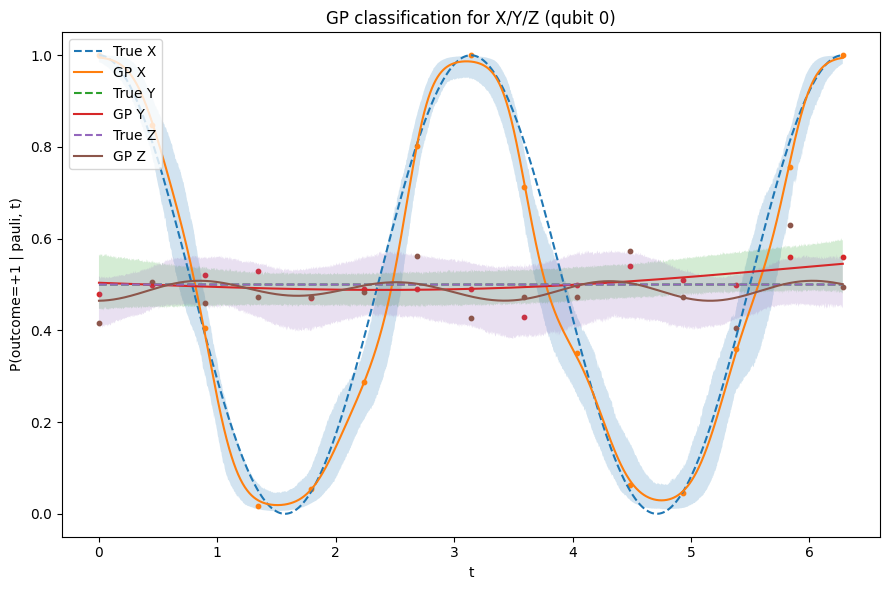

In [34]:
# Plot predictions with empirical p_hat and true curve
plt.figure(figsize=(9, 6))

for pauli, out in results.items():
    prob_np = out['prob'].detach().cpu().numpy()
    lower_np = out['lower'].detach().cpu().numpy()
    upper_np = out['upper'].detach().cpu().numpy()

    # true probability for outcome +1 on qubit 0, given pauli basis
    proj = pauli_eigen[pauli][+1] * pauli_eigen[pauli][+1].dag()
    proj_full = qt.tensor(proj, qt.qeye(2))
    true_prob = [qt.expect(proj_full, psi) for psi in result.states]
    true_prob = np.real(true_prob)

    data_filt = out['data']
    t_hat, p_hat = compute_empirical_p(data_filt)

    plt.plot(tlist, true_prob, linestyle='--', label=f'True {pauli}')
    plt.plot(tlist, prob_np, label=f'GP {pauli}')
    plt.fill_between(tlist, lower_np, upper_np, alpha=0.2)
    plt.scatter(t_hat, p_hat, s=10)
    print(true_prob)

plt.xlabel('t')
plt.ylabel('P(outcome=+1 | pauli, t)')
plt.title('GP classification for X/Y/Z (qubit 0)')
plt.legend(loc='upper left')
plt.tight_layout()


Iter 200/1500 - Loss: 0.4070
Iter 400/1500 - Loss: 0.4030
Iter 600/1500 - Loss: 0.4016
Iter 800/1500 - Loss: 0.4008
Iter 1000/1500 - Loss: 0.4004
Iter 1200/1500 - Loss: 0.4001
Iter 1400/1500 - Loss: 0.3999
Iter 200/1500 - Loss: 0.4185
Iter 400/1500 - Loss: 0.4155
Iter 600/1500 - Loss: 0.4143
Iter 800/1500 - Loss: 0.4138
Iter 1000/1500 - Loss: 0.4135
Iter 1200/1500 - Loss: 0.4132
Iter 1400/1500 - Loss: 0.4131
Iter 200/1500 - Loss: 0.4119
Iter 400/1500 - Loss: 0.4091
Iter 600/1500 - Loss: 0.4085
Iter 800/1500 - Loss: 0.4080
Iter 1000/1500 - Loss: 0.4074
Iter 1200/1500 - Loss: 0.4070
Iter 1400/1500 - Loss: 0.4068
Iter 200/1500 - Loss: 0.3692
Iter 400/1500 - Loss: 0.3715
Iter 600/1500 - Loss: 0.3642
Iter 800/1500 - Loss: 0.3636
Iter 1000/1500 - Loss: 0.3631
Iter 1200/1500 - Loss: 0.3629
Iter 1400/1500 - Loss: 0.3627


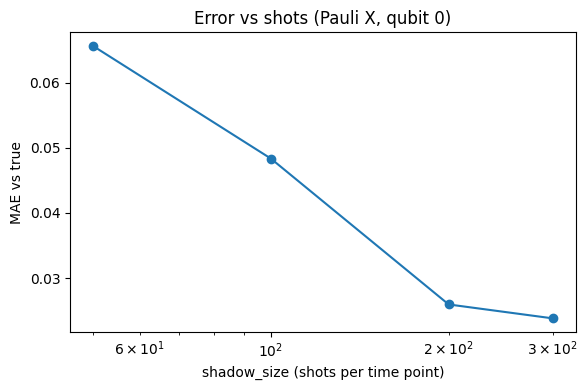

In [35]:
# Shot-scaling experiment (Pauli X on qubit 0)
t_min = float(tlist.min())
t_max = float(tlist.max())
if normalize_time_flag:
    t_norm = (tlist - t_min) / (t_max - t_min)
    test_x = torch.tensor(t_norm, dtype=torch.float32).unsqueeze(-1)
else:
    test_x = torch.tensor(tlist, dtype=torch.float32).unsqueeze(-1)

shadow_sizes = [50, 100, 200, 300]
errors = []

for ss in shadow_sizes:
    df = build_measurement_df(ss, indices, result, tlist, qubit_num)
    train_x, train_y, data_filt, _, _ = build_dataset(
        df, qubit=0, pauli='X', normalize_time_flag=normalize_time_flag, t_min=t_min, t_max=t_max
    )
    if len(train_x) < 5:
        errors.append(float('nan'))
        continue
    model, likelihood = train_gp_classifier(
        train_x, train_y, num_inducing=min(64, train_x.size(0)), training_iter=1500, lr=0.01, print_every=200, period_length=1.0 if normalize_time_flag else 2 * np.pi
    )
    prob_mean, _, _, _, _ = predict_gp_classifier(model, likelihood, test_x, num_samples=200)
    prob_np = prob_mean.detach().cpu().numpy()

    proj = pauli_eigen['X'][+1] * pauli_eigen['X'][+1].dag()
    proj_full = qt.tensor(proj, qt.qeye(2))
    true_prob = [qt.expect(proj_full, psi) for psi in result.states]
    true_prob = np.real(true_prob)

    err = mae_against_true(tlist, prob_np, tlist, true_prob)
    errors.append(err)

plt.figure(figsize=(6, 4))
plt.plot(shadow_sizes, errors, marker='o')
plt.xscale('log')
plt.xlabel('shadow_size (shots per time point)')
plt.ylabel('MAE vs true')
plt.title('Error vs shots (Pauli X, qubit 0)')
plt.tight_layout()
plt.show()
plt.close()
